<a href="https://colab.research.google.com/github/wesleypiaui/challenger_alura_data_science1/blob/main/AluraStoreBr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [39]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [40]:
from urllib.request import urlopen
import csv

urls = [url1, url2, url3, url4]

faturamento_loja1 = loja['Preço'].astype(float).sum()
faturamento_loja2 = loja2['Preço'].astype(float).sum()
faturamento_loja3 = loja3['Preço'].astype(float).sum()
faturamento_loja4 = loja4['Preço'].astype(float).sum()

# Mostrar os resultados
print(f"Faturamento Loja 1: R${faturamento_loja1:.2f}")
print(f"Faturamento Loja 2: R${faturamento_loja2:.2f}")
print(f"Faturamento Loja 3: R${faturamento_loja3:.2f}")
print(f"Faturamento Loja 4: R${faturamento_loja4:.2f}")

# Faturamento total de todas as lojas
faturamento_total = faturamento_loja1 + faturamento_loja2 + faturamento_loja3 + faturamento_loja4
print(f"\nFaturamento total de todas as lojas: R${faturamento_total:.2f}")


Faturamento Loja 1: R$1534509.12
Faturamento Loja 2: R$1488459.06
Faturamento Loja 3: R$1464025.03
Faturamento Loja 4: R$1384497.58

Faturamento total de todas as lojas: R$5871490.79


# 2. Vendas por Categoria


In [24]:
# Função para calcular e mostrar as vendas por categoria de uma loja
def vendas_por_categoria(loja, numero):
    vendas = loja.groupby('Categoria do Produto')['Preço'].sum()
    print(f"\nVendas por categoria na Loja {numero}:")
    print(vendas)

# Mostrar resultados para cada loja
vendas_por_categoria(loja, 1)
vendas_por_categoria(loja2, 2)
vendas_por_categoria(loja3, 3)
vendas_por_categoria(loja4, 4)



Vendas por categoria na Loja 1:
Categoria do Produto
brinquedos                23993.78
eletrodomesticos         484913.36
eletronicos              572659.23
esporte e lazer           52387.55
instrumentos musicais    121731.69
livros                    11713.92
moveis                   250178.11
utilidades domesticas     16931.48
Name: Preço, dtype: float64

Vendas por categoria na Loja 2:
Categoria do Produto
brinquedos                21262.21
eletrodomesticos         464758.13
eletronicos              547773.71
esporte e lazer           46326.09
instrumentos musicais    139987.03
livros                    13454.35
moveis                   235234.68
utilidades domesticas     19662.86
Name: Preço, dtype: float64

Vendas por categoria na Loja 3:
Categoria do Produto
brinquedos                25869.20
eletrodomesticos         438984.89
eletronicos              547699.92
esporte e lazer           47456.10
instrumentos musicais    103174.45
livros                    12664.70
moveis      

# 3. Média de Avaliação das Lojas

In [25]:
def avaliacao_media(loja, numero):
    media = loja['Avaliação da compra'].mean()
    print(f"Avaliação média na Loja {numero}: {media:.2f}")

# Mostrar resultados para cada loja
avaliacao_media(loja, 1)
avaliacao_media(loja2, 2)
avaliacao_media(loja3, 3)
avaliacao_media(loja4, 4)

Avaliação média na Loja 1: 3.98
Avaliação média na Loja 2: 4.04
Avaliação média na Loja 3: 4.05
Avaliação média na Loja 4: 4.00


# 4. Produtos Mais e Menos Vendidos

In [26]:
# Ler todos os CSVs e adicionar uma coluna 'Loja'
df_total = pd.concat(
    [pd.read_csv(url).assign(Loja=f"Loja {i+1}") for i, url in enumerate(urls)],
    ignore_index=True
)

# Garantir os tipos corretos
df_total['Preço'] = df_total['Preço'].astype(float)
df_total['Quantidade de parcelas'] = df_total['Quantidade de parcelas'].astype(int)

# A receita é simplesmente o Preço (não multiplicamos pela quantidade de parcelas)
df_total['Receita'] = df_total['Preço']

# Agrupar por Loja e Produto somando a receita
vendas = df_total.groupby(['Loja', 'Produto'])['Receita'].sum().reset_index()

# Função para mostrar os 3 produtos que mais e menos dinheiro geraram
def top_produtos(loja):
    dados = vendas[vendas['Loja'] == loja]

    top_mais_vendidos = dados.sort_values(by='Receita', ascending=False).head(3)
    top_menos_vendidos = dados.sort_values(by='Receita', ascending=True).head(3)

    print(f"\n{loja} - TOP 3 produtos que MAIS dinheiro geraram:")
    for _, linha in top_mais_vendidos.iterrows():
        print(f"  {linha['Produto']} - Receita: R${linha['Receita']:.2f}")

    print(f"\n{loja} - TOP 3 produtos que MENOS dinheiro geraram:")
    for _, linha in top_menos_vendidos.iterrows():
        print(f"  {linha['Produto']} - Receita: R${linha['Receita']:.2f}")

# Lista única de lojas
lojas_unicas = vendas['Loja'].unique()

# Mostrar resultados para cada loja
for loja in lojas_unicas:
    top_produtos(loja)


Loja 1 - TOP 3 produtos que MAIS dinheiro geraram:
  TV Led UHD 4K - Receita: R$189534.28
  Geladeira - Receita: R$149524.28
  Celular Plus X42 - Receita: R$130536.40

Loja 1 - TOP 3 produtos que MENOS dinheiro geraram:
  Corda de pular - Receita: R$870.89
  Dinossauro Rex - Receita: R$918.40
  Cubo mágico 8x8 - Receita: R$929.27

Loja 2 - TOP 3 produtos que MAIS dinheiro geraram:
  Celular Plus X42 - Receita: R$150967.83
  TV Led UHD 4K - Receita: R$137833.06
  Geladeira - Receita: R$130176.48

Loja 2 - TOP 3 produtos que MENOS dinheiro geraram:
  Cubo mágico 8x8 - Receita: R$858.22
  Dinossauro Rex - Receita: R$1027.41
  Corda de pular - Receita: R$1142.54

Loja 3 - TOP 3 produtos que MAIS dinheiro geraram:
  Geladeira - Receita: R$133185.99
  TV Led UHD 4K - Receita: R$128892.11
  Celular Plus X42 - Receita: R$124300.84

Loja 3 - TOP 3 produtos que MENOS dinheiro geraram:
  Cubo mágico 8x8 - Receita: R$853.81
  Dinossauro Rex - Receita: R$1060.78
  Corda de pular - Receita: R$1137.

# 5. Frete Médio por Loja


In [27]:
# Garantir que o custo de envio é numérico
df_total['Frete'] = df_total['Frete'].astype(float)

# Agrupar por loja e calcular a média do custo de envio
envio_medio = df_total.groupby('Loja')['Frete'].mean()

# Mostrar resultados
print("\nEnvio médio por loja:")
for loja, medio in envio_medio.items():
    print(f"{loja}: R${medio:.2f}")


Envio médio por loja:
Loja 1: R$34.69
Loja 2: R$33.62
Loja 3: R$33.07
Loja 4: R$31.28


# 6. Avaliação por loja

In [42]:
def avaliacao_loja(loja, numero):
    # Calcular as avaliações para a loja especificada
    avaliacoes_loja = loja['Avaliação da compra'].value_counts().sort_index()

    # Retornar as avaliações
    return avaliacoes_loja

# Obter avaliações para cada loja
avaliacoes_loja1 = avaliacao_loja(loja, 1)
avaliacoes_loja2 = avaliacao_loja(loja2, 2)
avaliacoes_loja3 = avaliacao_loja(loja3, 3)
avaliacoes_loja4 = avaliacao_loja(loja4, 4)

# Criar DataFrame com todas as lojas
dados_avaliacoes = pd.DataFrame({
    '1': [avaliacoes_loja1.get(1, 0), avaliacoes_loja2.get(1, 0), avaliacoes_loja3.get(1, 0), avaliacoes_loja4.get(1, 0)],
    '2': [avaliacoes_loja1.get(2, 0), avaliacoes_loja2.get(2, 0), avaliacoes_loja3.get(2, 0), avaliacoes_loja4.get(2, 0)],
    '3': [avaliacoes_loja1.get(3, 0), avaliacoes_loja2.get(3, 0), avaliacoes_loja3.get(3, 0), avaliacoes_loja4.get(3, 0)],
    '4': [avaliacoes_loja1.get(4, 0), avaliacoes_loja2.get(4, 0), avaliacoes_loja3.get(4, 0), avaliacoes_loja4.get(4, 0)],
    '5': [avaliacoes_loja1.get(5, 0), avaliacoes_loja2.get(5, 0), avaliacoes_loja3.get(5, 0), avaliacoes_loja4.get(5, 0)]
}, index=['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'])

# Mostrar o DataFrame
print(dados_avaliacoes)

          1   2    3    4     5
Loja 1  319  86  218  444  1292
Loja 2  273  93  209  482  1302
Loja 3  297  79  193  434  1356
Loja 4  310  85  210  453  1300


## 7. Gráficos

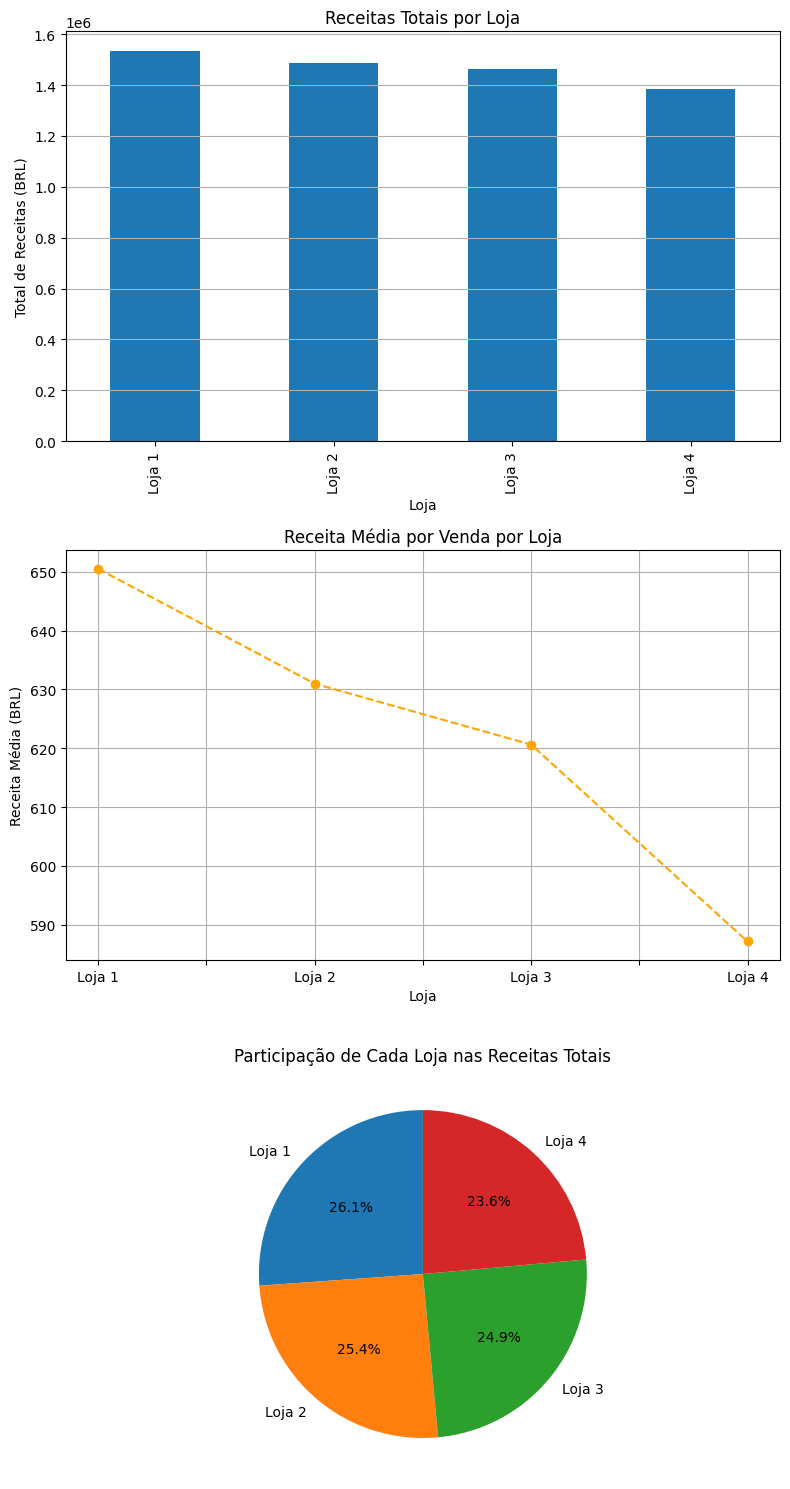

In [43]:
import matplotlib.pyplot as plt

def gerar_graficos(df_total):
    # Garantir tipo correto
    df_total['Preço'] = df_total['Preço'].astype(float)

    # A receita de cada venda é simplesmente o preço
    df_total['Receita'] = df_total['Preço']

    # Agrupar dados
    receitas_totais = df_total.groupby('Loja')['Receita'].sum()
    receita_media = df_total.groupby('Loja')['Receita'].mean()
    distribuicao_receitas = receitas_totais

    # Configurar o layout dos gráficos
    fig, axs = plt.subplots(3, 1, figsize=(8, 15))

    # 1. Barra vertical: Total de receitas
    receitas_totais.plot(kind='bar', ax=axs[0])
    axs[0].set_title('Receitas Totais por Loja')
    axs[0].set_ylabel('Total de Receitas (BRL)')
    axs[0].set_xlabel('Loja')
    axs[0].grid(axis='y')

    # 2. Linha: Receita média por venda
    receita_media.plot(kind='line', marker='o', linestyle='--', color='orange', ax=axs[1])
    axs[1].set_title('Receita Média por Venda por Loja')
    axs[1].set_ylabel('Receita Média (BRL)')
    axs[1].set_xlabel('Loja')
    axs[1].grid(True)

    # 3. Pizza: Distribuição do total
    distribuicao_receitas.plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=axs[2])
    axs[2].set_title('Participação de Cada Loja nas Receitas Totais')
    axs[2].set_ylabel('')

    # Ajustar layout
    plt.tight_layout()
    plt.show()

# Chamar a função com o DataFrame df_total
gerar_graficos(df_total)
